<a href="https://colab.research.google.com/github/ruhie18/customer-churn-revenue-intelligence/blob/main/01_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
url = "https://raw.githubusercontent.com/ruhie18/customer-churn-revenue-intelligence/refs/heads/main/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape (rows, columns): (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:

df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
problem_rows = df[df['TotalCharges_numeric'].isnull()]
print(f"Number of problem rows: {len(problem_rows)}")
problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Number of problem rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [6]:

df['TotalCharges'] = df['TotalCharges_numeric']
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop(columns=['TotalCharges_numeric'])
print("Missing values in TotalCharges now:", df['TotalCharges'].isnull().sum())
print("Data type of TotalCharges now:", df['TotalCharges'].dtype)

Missing values in TotalCharges now: 0
Data type of TotalCharges now: float64


In [7]:
print("Fully duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

Fully duplicate rows: 0
Duplicate customerIDs: 0


In [8]:
for col in ['Contract', 'PaymentMethod', 'InternetService', 'Churn']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [9]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 months'
    elif tenure <= 24:
        return '13-24 months'
    elif tenure <= 48:
        return '25-48 months'
    else:
        return '49+ months'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

df['TenureGroup'].value_counts()

,count
TenureGroup,
49+ months,2239
0-12 months,2186
25-48 months,1594
13-24 months,1024


In [10]:
service_columns = ['PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']

def count_services(row):
    count = 0
    for col in service_columns:
        if row[col] not in ['No', 'No internet service', 'No phone service']:
            count += 1
    return count

df['NumServices'] = df.apply(count_services, axis=1)

df['NumServices'].value_counts().sort_index()

,count
NumServices,
1,1264
2,859
3,846
4,965
5,922
6,908
7,676
8,395
9,208


In [11]:
df['MonthlyRevenueGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 100, df['MonthlyCharges'].max()],
    labels=['Low (<$35)', 'Medium ($35-70)', 'High ($70-100)', 'Very High ($100+)']
)

df['MonthlyRevenueGroup'].value_counts()

,count
MonthlyRevenueGroup,
High ($70-100),2681
Low (<$35),1735
Medium ($35-70),1725
Very High ($100+),902


In [12]:
def customer_value(row):
    if row['TotalCharges'] >= df['TotalCharges'].quantile(0.75):
        return 'High Value'
    elif row['TotalCharges'] >= df['TotalCharges'].quantile(0.25):
        return 'Medium Value'
    else:
        return 'Low Value'

df['CustomerValueGroup'] = df.apply(customer_value, axis=1)

df['CustomerValueGroup'].value_counts()

,count
CustomerValueGroup,
Medium Value,3522
High Value,1761
Low Value,1760


In [13]:
print("Final shape:", df.shape)
print("\nColumn list:")
print(df.columns.tolist())
print("\nFinal missing values check:")
print(df.isnull().sum().sum(), "total missing values")

df.head()

Final shape: (7043, 25)

Column list:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'NumServices', 'MonthlyRevenueGroup', 'CustomerValueGroup']

Final missing values check:
0 total missing values


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,NumServices,MonthlyRevenueGroup,CustomerValueGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months,2,Low (<$35),Low Value
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,25-48 months,4,Medium ($35-70),Medium Value
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months,4,Medium ($35-70),Low Value
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 months,4,Medium ($35-70),Medium Value
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months,2,High ($70-100),Low Value


In [14]:
df.to_csv('cleaned_telco_churn.csv', index=False)
print("Saved cleaned_telco_churn.csv")

Saved cleaned_telco_churn.csv


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


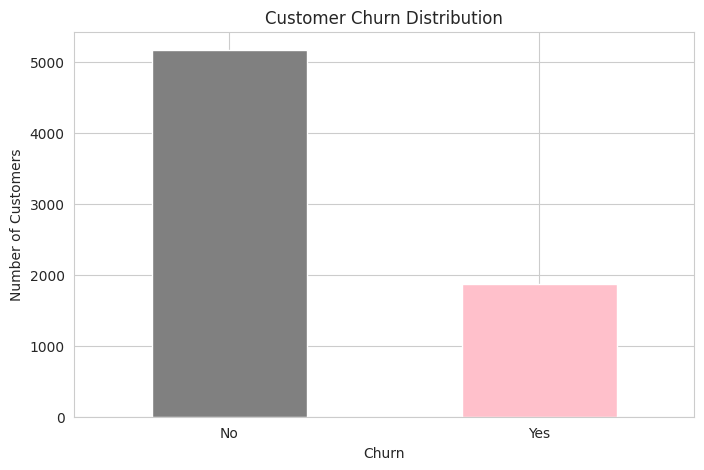

In [29]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

plt.figure()
df['Churn'].value_counts().plot(kind='bar', color=['grey', 'pink'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


<Figure size 800x500 with 0 Axes>

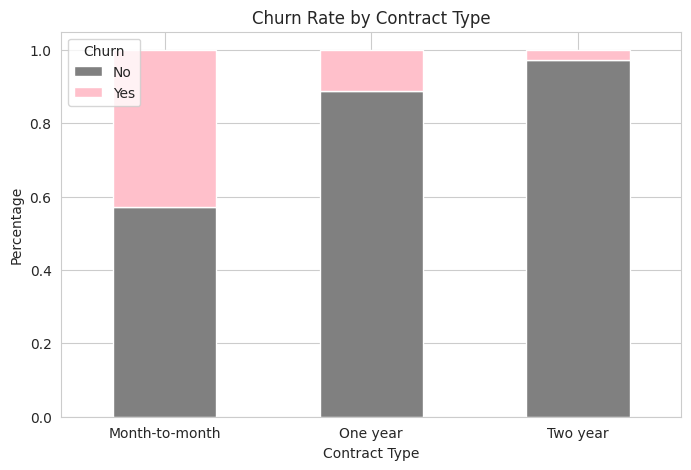

In [27]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_churn)

plt.figure()
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar', stacked=True, color=['grey', 'pink'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

Churn                No        Yes
TenureGroup                       
0-12 months   52.561757  47.438243
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49+ months    90.486824   9.513176


<Figure size 800x500 with 0 Axes>

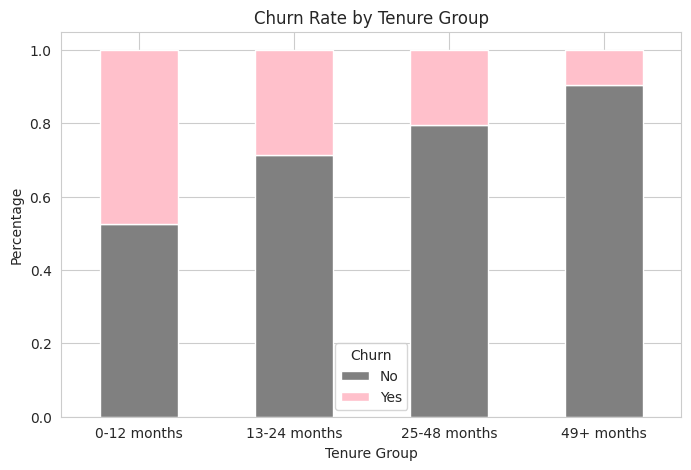

In [28]:
tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100
print(tenure_churn)

plt.figure()
pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index').loc[['0-12 months', '13-24 months', '25-48 months', '49+ months']].plot(kind='bar', stacked=True, color=['grey', 'pink'])
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

/tmp/ipykernel_768/1662281071.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', order=['No', 'Yes'], palette=['grey', 'pink'])


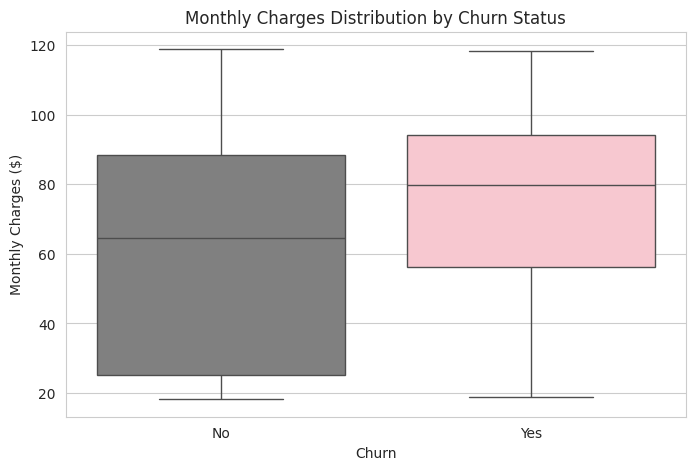

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [30]:
plt.figure()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', order=['No', 'Yes'], palette=['grey', 'pink'])
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].mean())

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


<Figure size 800x500 with 0 Axes>

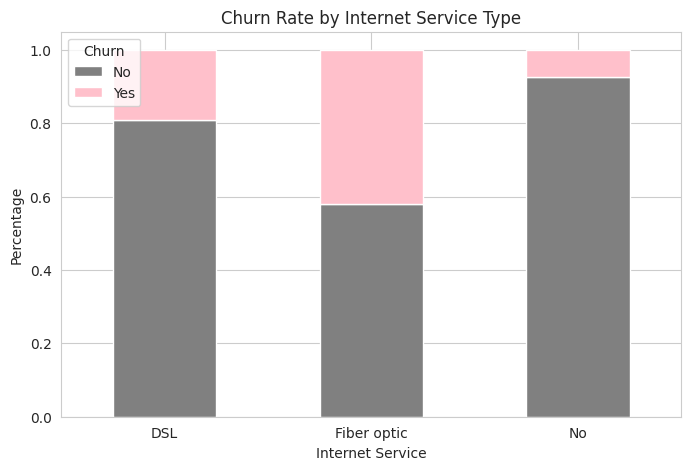

In [31]:
service_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print(service_churn)

plt.figure()
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')[['No','Yes']].plot(kind='bar', stacked=True, color=['grey', 'pink'])
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

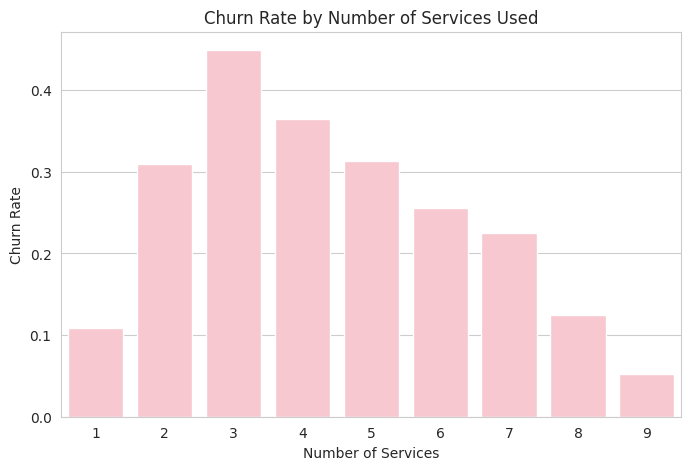

In [32]:
plt.figure()
sns.barplot(data=df, x='NumServices', y=df['Churn'].map({'No': 0, 'Yes': 1}), color='pink', errorbar=None)
plt.title('Churn Rate by Number of Services Used')
plt.xlabel('Number of Services')
plt.ylabel('Churn Rate')
plt.show()

CustomerValueGroup
Medium Value    209763.35
High Value      164658.75
Low Value        81694.50
Name: MonthlyCharges, dtype: float64


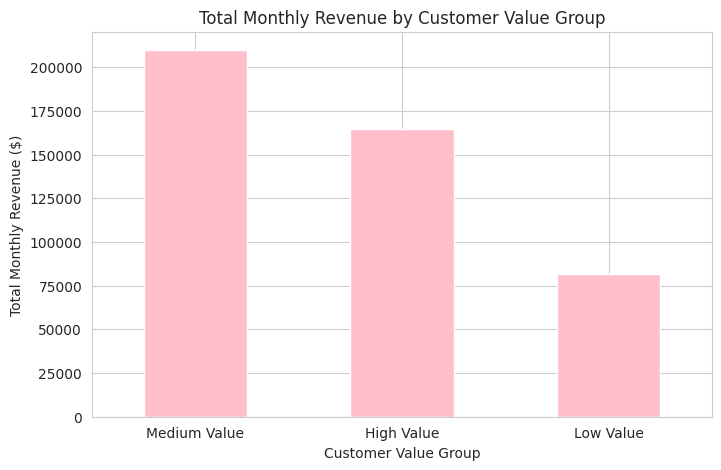

In [33]:
revenue_by_segment = df.groupby('CustomerValueGroup')['MonthlyCharges'].sum().sort_values(ascending=False)
print(revenue_by_segment)

plt.figure()
revenue_by_segment.plot(kind='bar', color='pink')
plt.title('Total Monthly Revenue by Customer Value Group')
plt.xlabel('Customer Value Group')
plt.ylabel('Total Monthly Revenue ($)')
plt.xticks(rotation=0)
plt.show()

Churn                      No        Yes
CustomerValueGroup                      
High Value          85.519591  14.480409
Low Value           56.704545  43.295455
Medium Value        75.809199  24.190801


<Figure size 800x500 with 0 Axes>

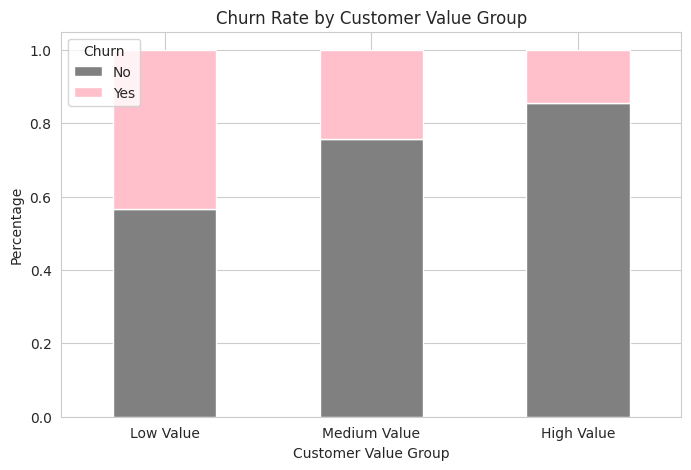

In [34]:
high_value_risk = pd.crosstab(df['CustomerValueGroup'], df['Churn'], normalize='index') * 100
print(high_value_risk)

plt.figure()
pd.crosstab(df['CustomerValueGroup'], df['Churn'], normalize='index')[['No','Yes']].reindex(['Low Value','Medium Value','High Value']).plot(kind='bar', stacked=True, color=['grey','pink'])
plt.title('Churn Rate by Customer Value Group')
plt.xlabel('Customer Value Group')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

Baseline churn rate: 26.5%
Contract type is the strongest churn driver — month-to-month customers churn far more than one/two-year contracts
Tenure matters — newer customers churn more (pending your Cell 17 confirmation)
Higher monthly charges correlate with higher churn
Fiber optic customers churn at nearly double the rate of DSL — a counter-intuitive, investigation-worthy finding
Service bundling protects against churn — customers with 6+ services are much stickier than those with 2-5
Medium Value customers drive the most total revenue, but Low Value customers churn the most — value and risk are inversely related here, not aligned

# STEP 4

In [35]:
import sqlite3
conn = sqlite3.connect(':memory:')
df.to_sql('customers', conn, index=False, if_exists='replace')
test_query = "SELECT COUNT(*) as total_customers FROM customers"
pd.read_sql(test_query, conn)

,total_customers
0,7043


In [36]:
query1 = """
SELECT
    Contract,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC
"""

pd.read_sql(query1, conn)

,Contract,total_customers,churned_customers,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [38]:
query2 = """
SELECT
    TenureGroup,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as churn_rate_pct
FROM customers
GROUP BY TenureGroup
ORDER BY churn_rate_pct DESC
"""

pd.read_sql(query2, conn)

,TenureGroup,total_customers,churned_customers,churn_rate_pct
0,0-12 months,2186,1037,47.44
1,13-24 months,1024,294,28.71
2,25-48 months,1594,325,20.39
3,49+ months,2239,213,9.51


In [39]:
query3 = """
SELECT
    CustomerValueGroup,
    COUNT(*) as num_customers,
    ROUND(SUM(MonthlyCharges), 2) as total_monthly_revenue,
    ROUND(AVG(MonthlyCharges), 2) as avg_monthly_revenue
FROM customers
GROUP BY CustomerValueGroup
ORDER BY total_monthly_revenue DESC
"""

pd.read_sql(query3, conn)

,CustomerValueGroup,num_customers,total_monthly_revenue,avg_monthly_revenue
0,Medium Value,3522,209763.35,59.56
1,High Value,1761,164658.75,93.50
2,Low Value,1760,81694.50,46.42


In [40]:
query4 = """
SELECT
    Churn,
    ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charges,
    ROUND(AVG(MonthlyCharges) - (SELECT AVG(MonthlyCharges) FROM customers), 2) as diff_from_overall_avg
FROM customers
GROUP BY Churn
"""

pd.read_sql(query4, conn)

,Churn,avg_monthly_charges,diff_from_overall_avg
0,No,61.27,-3.50
1,Yes,74.44,9.68


In [41]:
query5 = """
SELECT
    customerID,
    MonthlyCharges,
    CustomerValueGroup,
    RANK() OVER (ORDER BY MonthlyCharges DESC) as revenue_rank
FROM customers
ORDER BY revenue_rank
LIMIT 10
"""

pd.read_sql(query5, conn)

,customerID,MonthlyCharges,CustomerValueGroup,revenue_rank
0,7569-NMZYQ,118.75,High Value,1
1,8984-HPEMB,118.65,High Value,2
2,5989-AXPUC,118.60,High Value,3
3,5734-EJKXG,118.60,High Value,3
4,8199-ZLLSA,118.35,High Value,5
5,9924-JPRMC,118.20,High Value,6
6,2889-FPWRM,117.80,High Value,7
7,3810-DVDQQ,117.60,High Value,8
8,9739-JLPQJ,117.50,High Value,9
9,2302-ANTDP,117.45,High Value,10


In [42]:
query6 = """
WITH customer_ranked AS (
    SELECT
        customerID,
        MonthlyCharges,
        TotalCharges,
        Churn,
        Contract,
        RANK() OVER (ORDER BY TotalCharges DESC) as value_rank
    FROM customers
)
SELECT *
FROM customer_ranked
WHERE value_rank <= 10
"""

pd.read_sql(query6, conn)

,customerID,MonthlyCharges,TotalCharges,Churn,Contract,value_rank
0,2889-FPWRM,117.80,8684.80,Yes,One year,1
1,7569-NMZYQ,118.75,8672.45,No,Two year,2
2,9739-JLPQJ,117.50,8670.10,No,Two year,3
3,9788-HNGUT,116.95,8594.40,No,Two year,4
4,8879-XUAHX,116.25,8564.75,No,Two year,5
5,9924-JPRMC,118.20,8547.15,No,Two year,6
6,0675-NCDYU,116.40,8543.25,No,Two year,7
7,6650-BWFRT,117.15,8529.50,No,Two year,8
8,0164-APGRB,114.90,8496.70,No,Two year,9
9,1488-PBLJN,116.85,8477.70,No,Two year,10


In [43]:
query7 = """
SELECT
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END), 2) as monthly_revenue_lost,
    ROUND(SUM(MonthlyCharges), 2) as total_monthly_revenue,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END) / SUM(MonthlyCharges), 2) as pct_revenue_at_risk
FROM customers
"""

pd.read_sql(query7, conn)

,monthly_revenue_lost,total_monthly_revenue,pct_revenue_at_risk
0,139130.85,456116.6,30.5


In [44]:
query8 = """
CREATE VIEW churn_summary_by_segment AS
SELECT
    CustomerValueGroup,
    Contract,
    COUNT(*) as num_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as churn_rate_pct,
    ROUND(SUM(MonthlyCharges), 2) as total_monthly_revenue
FROM customers
GROUP BY CustomerValueGroup, Contract
"""

conn.execute(query8)
print("View created successfully")

# Now query the view like a regular table
pd.read_sql("SELECT * FROM churn_summary_by_segment ORDER BY churn_rate_pct DESC", conn)

View created successfully


,CustomerValueGroup,Contract,num_customers,churned,churn_rate_pct,total_monthly_revenue
0,Low Value,Month-to-month,1525,754,49.44,76086.45
1,Medium Value,Month-to-month,1955,772,39.49,143335.95
2,High Value,Month-to-month,395,129,32.66,37871.75
3,High Value,One year,543,88,16.21,51501.75
4,Medium Value,One year,790,70,8.86,41133.30
5,Low Value,One year,140,8,5.71,3181.55
6,High Value,Two year,823,38,4.62,75285.25
7,Medium Value,Two year,777,10,1.29,25294.10
8,Low Value,Two year,95,0,0.00,2426.50


Churn rate by contract type — validated Python findings in SQL (month-to-month highest at ~42.7%)
Churn rate by tenure group — confirmed newer customers churn more
Revenue by customer value group — Medium Value drives most total revenue
Average monthly charges by churn status (subquery) — showed churned customers pay above the company average
Top 10 customers by revenue (window function — RANK() OVER)
Top 10 lifetime-value customers (CTE — WITH ... AS)
Total revenue tied to churned customers (aggregate + CASE WHEN) — your dollar-value "revenue lost" headline number
Churn summary by segment (View) — reusable cross-tab of Value Group × Contract Type

# STEP 5

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

model_df = df.drop(columns=['customerID', 'TenureGroup', 'MonthlyRevenueGroup', 'CustomerValueGroup'])
X = model_df.drop(columns=['Churn'])
y = model_df['Churn'].map({'No': 0, 'Yes': 1})
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("\nShape after encoding:", X_encoded.shape)
X_encoded.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,NumServices,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,2,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,4,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,4,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,4,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,2,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Drop columns that shouldn't be used as predictive features
model_df = df.drop(columns=['customerID', 'TenureGroup', 'MonthlyRevenueGroup', 'CustomerValueGroup'])


X = model_df.drop(columns=['Churn'])
y = model_df['Churn'].map({'No': 0, 'Yes': 1})

categorical_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)


X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nShape after encoding:", X_encoded.shape)
X_encoded.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,NumServices,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,2,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,4,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,4,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,4,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,2,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nChurn rate in training set:", y_train.mean().round(3))
print("Churn rate in test set:", y_test.mean().round(3))

# Scale numeric features (important for Logistic Regression)
scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nScaling complete")

Training set size: (5634, 31)
Test set size: (1409, 31)

Churn rate in training set: 0.265
Churn rate in test set: 0.265

Scaling complete


In [49]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [50]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated")
print("\nSample predictions (first 10):")
for i in range(10):
    print(f"Actual: {y_test.iloc[i]}, Predicted: {y_pred[i]}, Churn Probability: {y_pred_proba[i]:.2f}")

Predictions generated

Sample predictions (first 10):
Actual: 0, Predicted: 0, Churn Probability: 0.05
Actual: 0, Predicted: 1, Churn Probability: 0.68
Actual: 0, Predicted: 0, Churn Probability: 0.06
Actual: 0, Predicted: 0, Churn Probability: 0.40
Actual: 0, Predicted: 0, Churn Probability: 0.02
Actual: 0, Predicted: 1, Churn Probability: 0.60
Actual: 0, Predicted: 0, Churn Probability: 0.45
Actual: 0, Predicted: 0, Churn Probability: 0.13
Actual: 0, Predicted: 0, Churn Probability: 0.00
Actual: 1, Predicted: 0, Churn Probability: 0.40


In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print("F1 Score: ", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_pred_proba), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy:  0.806
Precision: 0.659
Recall:    0.559
F1 Score:  0.605
ROC-AUC:   0.842

Confusion Matrix:
[[927 108]
 [165 209]]

Full Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



#step 6

In [52]:
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': log_reg.coef_[0]
})

coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("Top 10 churn drivers (by coefficient magnitude):")
coefficients[['Feature', 'Coefficient']].head(10)

Top 10 churn drivers (by coefficient magnitude):


,Feature,Coefficient
26,Contract_Two year,-1.324861
1,tenure,-1.257159
11,InternetService_Fiber optic,1.232768
25,Contract_One year,-0.690058
2,MonthlyCharges,-0.538375
3,TotalCharges,0.531449
14,OnlineSecurity_Yes,-0.506003
8,PhoneService_Yes,-0.487702
20,TechSupport_Yes,-0.455693
4,NumServices,0.391340


#step 7

In [53]:

X_full_scaled = X_encoded.copy()
X_full_scaled[numeric_cols] = scaler.transform(X_encoded[numeric_cols])
df['ChurnProbability'] = log_reg.predict_proba(X_full_scaled)[:, 1]

print("Churn probability generated for all customers")
df[['customerID', 'Churn', 'ChurnProbability']].head(10)

Churn probability generated for all customers


,customerID,Churn,ChurnProbability
0,7590-VHVEG,No,0.614339
1,5575-GNVDE,No,0.045106
2,3668-QPYBK,Yes,0.299617
3,7795-CFOCW,No,0.028844
4,9237-HQITU,Yes,0.691986
5,9305-CDSKC,Yes,0.795509
6,1452-KIOVK,No,0.484831
7,6713-OKOMC,No,0.292593
8,7892-POOKP,Yes,0.621510
9,6388-TABGU,No,0.010713


RiskCategory
Low Risk         4037
Medium Risk      1446
High Risk        1351
Critical Risk     209
Name: count, dtype: int64


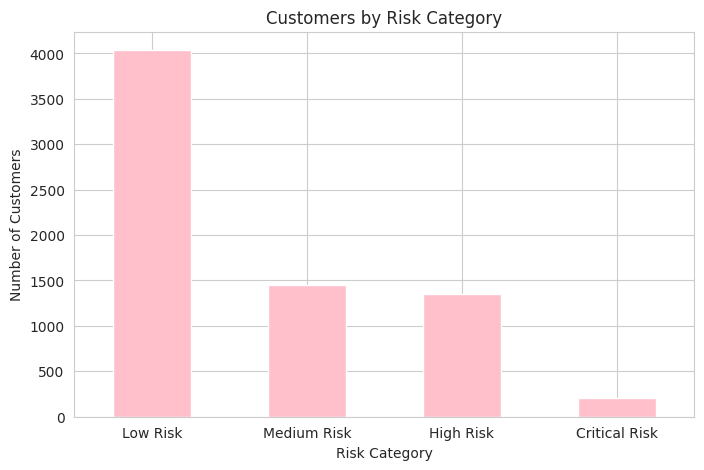

In [54]:
def risk_category(prob):
    if prob < 0.25:
        return 'Low Risk'
    elif prob < 0.50:
        return 'Medium Risk'
    elif prob < 0.75:
        return 'High Risk'
    else:
        return 'Critical Risk'

df['RiskCategory'] = df['ChurnProbability'].apply(risk_category)

print(df['RiskCategory'].value_counts())

plt.figure()
df['RiskCategory'].value_counts().reindex(['Low Risk','Medium Risk','High Risk','Critical Risk']).plot(kind='bar', color='pink')
plt.title('Customers by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

#step 8

In [55]:
df['RevenueAtRisk'] = df['MonthlyCharges'] * df['ChurnProbability']

print("Total monthly revenue at risk: $", round(df['RevenueAtRisk'].sum(), 2))

df.groupby('RiskCategory')['RevenueAtRisk'].sum().sort_values(ascending=False)

Total monthly revenue at risk: $ 139943.59


,RevenueAtRisk
RiskCategory,
High Risk,67362.535744
Medium Risk,37823.580500
Low Risk,20085.743148
Critical Risk,14671.730007


# step 9

In [56]:
def simple_segment(row):
    high_value = row['CustomerValueGroup'] == 'High Value'
    high_risk = row['RiskCategory'] in ['High Risk', 'Critical Risk']
    if high_value and high_risk: return 'High Value / High Risk'
    elif high_value and not high_risk: return 'High Value / Low Risk'
    elif not high_value and high_risk: return 'Low-Med Value / High Risk'
    else: return 'Low-Med Value / Low Risk'

df['Segment'] = df.apply(simple_segment, axis=1)
df['Segment'].value_counts()

,count
Segment,
Low-Med Value / Low Risk,3777
High Value / Low Risk,1706
Low-Med Value / High Risk,1505
High Value / High Risk,55


# step 10

In [57]:
tableau_export = df[[
    'customerID', 'Churn', 'ChurnProbability', 'RiskCategory',
    'MonthlyCharges', 'TotalCharges', 'RevenueAtRisk',
    'Contract', 'tenure', 'TenureGroup',
    'CustomerValueGroup', 'Segment', 'NumServices', 'InternetService'
]].copy()

tableau_export['ChurnProbability'] = tableau_export['ChurnProbability'].round(4)
tableau_export['RevenueAtRisk'] = tableau_export['RevenueAtRisk'].round(2)

tableau_export.to_csv('tableau_churn_data.csv', index=False)

print("Exported:", tableau_export.shape)
tableau_export.head()

Exported: (7043, 14)


,customerID,Churn,ChurnProbability,RiskCategory,MonthlyCharges,TotalCharges,RevenueAtRisk,Contract,tenure,TenureGroup,CustomerValueGroup,Segment,NumServices,InternetService
0,7590-VHVEG,No,0.6143,High Risk,29.85,29.85,18.34,Month-to-month,1,0-12 months,Low Value,Low-Med Value / High Risk,2,DSL
1,5575-GNVDE,No,0.0451,Low Risk,56.95,1889.50,2.57,One year,34,25-48 months,Medium Value,Low-Med Value / Low Risk,4,DSL
2,3668-QPYBK,Yes,0.2996,Medium Risk,53.85,108.15,16.13,Month-to-month,2,0-12 months,Low Value,Low-Med Value / Low Risk,4,DSL
3,7795-CFOCW,No,0.0288,Low Risk,42.30,1840.75,1.22,One year,45,25-48 months,Medium Value,Low-Med Value / Low Risk,4,DSL
4,9237-HQITU,Yes,0.6920,High Risk,70.70,151.65,48.92,Month-to-month,2,0-12 months,Low Value,Low-Med Value / High Risk,2,Fiber optic
